In [1]:
# ============================================================
# 00 — CONNECT GOOGLE DRIVE / PROJECT
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# ============================================================
# PROJECT PATH
# ============================================================

from pathlib import Path
import sys

PROJECT_DIR = Path(
    "/content/drive/MyDrive/FitnessML_Master"
)

print(f"Project directory: {PROJECT_DIR}")
print(f"Exists: {PROJECT_DIR.exists()}")

Project directory: /content/drive/MyDrive/FitnessML_Master
Exists: True


In [3]:
# ============================================================
# ADD PROJECT TO PYTHON PATH
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))
import config_fitbit as config

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 100)

print("=" * 70)
print("FITBIT MODEL INTERPRETABILITY")
print("=" * 70)

print("Project added to Python path.")
print(f"Project directory: {config.PROJECT_DIR}")

FITBIT MODEL INTERPRETABILITY
Project added to Python path.
Project directory: /content/drive/MyDrive/FitnessML_Master


In [4]:
# ============================================================
# FIND PROCESSED DATASETS
# ============================================================

processed_dir = Path(config.PROJECT_DIR) / "data" / "processed"

print("=" * 70)
print("PROCESSED DATASETS")
print("=" * 70)

if not processed_dir.exists():
    raise FileNotFoundError(
        f"Processed directory not found: {processed_dir}"
    )

processed_files = sorted(processed_dir.glob("*.csv"))

for i, path in enumerate(processed_files, 1):
    size_mb = path.stat().st_size / (1024 * 1024)
    print(f"{i:02d}. {path.name:<45} {size_mb:.2f} MB")

print(f"\nCSV files found: {len(processed_files)}")

PROCESSED DATASETS
01. fitbit_daily_processed.csv                    0.11 MB
02. fitbit_modeling_features.csv                  0.48 MB

CSV files found: 2


In [5]:
# ============================================================
# LOAD MODELING DATASET
# ============================================================

modeling_path = (
    Path(config.PROJECT_DIR)
    / "data"
    / "processed"
    / "fitbit_modeling_features.csv"
)

print("=" * 70)
print("LOADING MODELING DATASET")
print("=" * 70)

modeling = pd.read_csv(modeling_path)

modeling["ActivityDate"] = pd.to_datetime(
    modeling["ActivityDate"]
)

print(f"Shape: {modeling.shape}")
print(f"Users: {modeling['Id'].nunique()}")
print(
    f"Date range: "
    f"{modeling['ActivityDate'].min().date()} → "
    f"{modeling['ActivityDate'].max().date()}"
)

display(modeling.head())

LOADING MODELING DATASET
Shape: (680, 68)
Users: 32
Date range: 2016-04-19 → 2016-05-11


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Calories_lag_1,Calories_lag_2,Calories_lag_3,Calories_lag_7,TotalSteps_lag_1,TotalSteps_lag_2,TotalSteps_lag_3,TotalSteps_lag_7,TotalDistance_lag_1,TotalDistance_lag_2,TotalDistance_lag_3,TotalDistance_lag_7,VeryActiveMinutes_lag_1,VeryActiveMinutes_lag_2,VeryActiveMinutes_lag_3,VeryActiveMinutes_lag_7,FairlyActiveMinutes_lag_1,FairlyActiveMinutes_lag_2,FairlyActiveMinutes_lag_3,FairlyActiveMinutes_lag_7,LightlyActiveMinutes_lag_1,LightlyActiveMinutes_lag_2,LightlyActiveMinutes_lag_3,LightlyActiveMinutes_lag_7,SedentaryMinutes_lag_1,SedentaryMinutes_lag_2,SedentaryMinutes_lag_3,SedentaryMinutes_lag_7,Calories_rolling_mean_3,Calories_rolling_std_3,Calories_rolling_mean_7,Calories_rolling_std_7,TotalSteps_rolling_mean_3,TotalSteps_rolling_std_3,TotalSteps_rolling_mean_7,TotalSteps_rolling_std_7,TotalDistance_rolling_mean_3,TotalDistance_rolling_std_3,TotalDistance_rolling_mean_7,TotalDistance_rolling_std_7,VeryActiveMinutes_rolling_mean_3,VeryActiveMinutes_rolling_std_3,VeryActiveMinutes_rolling_mean_7,VeryActiveMinutes_rolling_std_7,LightlyActiveMinutes_rolling_mean_3,LightlyActiveMinutes_rolling_std_3,LightlyActiveMinutes_rolling_mean_7,LightlyActiveMinutes_rolling_std_7,SedentaryMinutes_rolling_mean_3,SedentaryMinutes_rolling_std_3,SedentaryMinutes_rolling_mean_7,SedentaryMinutes_rolling_std_7,target_calories_next_day
0,1503960366,2016-04-19,15506,9.88,9.88,0.0,3.53,1.32,5.03,0.0,50,31,264,775,2035,1921.0,1728.0,1863.0,1985.0,13019.0,9705.0,12669.0,13162.0,8.59,6.48,8.16,8.50,42.0,38.0,36.0,25.0,16.0,20.0,10.0,13.0,233.0,164.0,221.0,328.0,1149.0,539.0,773.0,728.0,1837.333333,99.026932,1830.714286,95.764841,11797.666667,1820.732087,11358.857143,1538.733833,7.743333,1.115004,7.388571,0.993654,38.666667,3.055050,31.571429,7.457818,206.000000,36.864617,221.857143,52.594133,820.333333,307.742316,844.142857,245.957604,1786.0
1,1503960366,2016-04-20,10544,6.68,6.68,0.0,1.96,0.48,4.24,0.0,28,12,205,818,1786,2035.0,1921.0,1728.0,1797.0,15506.0,13019.0,9705.0,10735.0,9.88,8.59,6.48,6.97,50.0,42.0,38.0,21.0,31.0,16.0,20.0,19.0,264.0,233.0,164.0,217.0,775.0,1149.0,539.0,776.0,1894.666667,155.184836,1837.857143,109.997619,12743.333333,2910.308288,11693.714286,2135.758079,8.316667,1.716401,7.585714,1.330662,43.333333,6.110101,35.142857,9.494359,220.333333,51.189192,212.714286,32.968239,821.000000,307.590637,850.857143,242.880923,1775.0
2,1503960366,2016-04-21,9819,6.34,6.34,0.0,1.34,0.35,4.65,0.0,19,8,211,838,1775,1786.0,2035.0,1921.0,1776.0,10544.0,15506.0,13019.0,10460.0,6.68,9.88,8.59,6.74,28.0,50.0,42.0,30.0,12.0,31.0,16.0,11.0,205.0,264.0,233.0,181.0,818.0,775.0,1149.0,1218.0,1914.000000,124.647503,1836.285714,110.754555,13023.000000,2481.002418,11666.428571,2151.211818,8.383333,1.609979,7.544286,1.357275,40.000000,11.135529,36.142857,8.008924,234.000000,29.512709,211.000000,33.020196,914.000000,204.648479,856.857143,241.236695,1827.0
3,1503960366,2016-04-22,12764,8.13,8.13,0.0,4.76,1.12,2.24,0.0,66,27,130,1217,1827,1775.0,1786.0,2035.0,1745.0,9819.0,10544.0,15506.0,9762.0,6.34,6.68,9.88,6.28,19.0,28.0,50.0,29.0,8.0,12.0,31.0,34.0,211.0,205.0,264.0,209.0,838.0,818.0,775.0,726.0,1865.333333,147.038544,1836.142857,110.845882,11956.333333,3095.400836,11574.857143,2223.551920,7.633333,1.953083,7.487143,1.404383,32.333333,15.947832,34.571429,10.195704,226.666667,32.470499,215.285714,30.313442,810.333333,32.192132,802.571429,181.876201,1949.0
4,1503960366,2016-04-23,14371,9.04,9.04,0.0,2.81,0.87,5.36,0.0,41,21,262,732,1949,1827.0,1775.0,1786.0,1863.0,12764.0,9819.0,10544.0,12669.0,8.13,6.34,6.68,8.16,66.0,19.0,28.0,36.0,27.0,8.0,12.0,10.0,130.0,211.0,205.0,221.0,1217.0,838.0,818.0,773.0,1796.000000,27.404379,1847.857143,103.711826,11042.333333,1534.440723,12003.714286,2101.796035,7.050000,

In [6]:
# ============================================================
# MODELING TARGET AND FEATURES
# ============================================================

target_column = "target_calories_next_day"

excluded_columns = [
    "Id",
    "ActivityDate",
    target_column
]

feature_columns = [
    col
    for col in modeling.columns
    if col not in excluded_columns
]

print("=" * 70)
print("MODELING STRUCTURE")
print("=" * 70)

print(f"Target: {target_column}")
print(f"Features: {len(feature_columns)}")
print(f"Users: {modeling['Id'].nunique()}")

print("\nFeature groups:")
print(f"  Base:    13")
print(f"  Lag:     28")
print(f"  Rolling: 24")
print(f"  Total:   {len(feature_columns)}")

MODELING STRUCTURE
Target: target_calories_next_day
Features: 65
Users: 32

Feature groups:
  Base:    13
  Lag:     28
  Rolling: 24
  Total:   65


In [7]:
# ============================================================
# TARGET / FEATURE CHECK
# ============================================================

print("=" * 70)
print("TARGET / FEATURE CHECK")
print("=" * 70)

print(f"Target missing: {modeling[target_column].isna().sum()}")
print(f"Feature missing cells: {modeling[feature_columns].isna().sum().sum()}")

print(
    f"Duplicate rows: "
    f"{modeling.duplicated(subset=['Id', 'ActivityDate']).sum()}"
)

TARGET / FEATURE CHECK
Target missing: 0
Feature missing cells: 0
Duplicate rows: 0


In [8]:
# ============================================================
# TEMPORAL TRAIN / TEST SPLIT
# ============================================================

print("=" * 70)
print("TEMPORAL SPLIT")
print("=" * 70)

split_date = pd.Timestamp("2016-05-07")

train = modeling[
    modeling["ActivityDate"] < split_date
].copy()

test = modeling[
    modeling["ActivityDate"] >= split_date
].copy()

print(f"Split date: {split_date.date()}")

print(
    f"Train: {len(train)} rows | "
    f"{train['ActivityDate'].min().date()} → "
    f"{train['ActivityDate'].max().date()}"
)

print(
    f"Test:  {len(test)} rows | "
    f"{test['ActivityDate'].min().date()} → "
    f"{test['ActivityDate'].max().date()}"
)

print(f"Train users: {train['Id'].nunique()}")
print(f"Test users:  {test['Id'].nunique()}")

TEMPORAL SPLIT
Split date: 2016-05-07
Train: 555 rows | 2016-04-19 → 2016-05-06
Test:  125 rows | 2016-05-07 → 2016-05-11
Train users: 32
Test users:  27


In [9]:
# ============================================================
# PREPARE MODEL INPUTS
# ============================================================

X_train = train[feature_columns].copy()
y_train = train[target_column].copy()

X_test = test[feature_columns].copy()
y_test = test[target_column].copy()

print("=" * 70)
print("MODEL INPUTS")
print("=" * 70)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

print(f"Missing X_train: {X_train.isna().sum().sum()}")
print(f"Missing X_test:  {X_test.isna().sum().sum()}")

MODEL INPUTS
X_train: (555, 65)
X_test:  (125, 65)
y_train: (555,)
y_test:  (125,)
Missing X_train: 0
Missing X_test:  0


In [10]:
# ============================================================
# TRAIN FINAL RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

predictions = rf_model.predict(X_test)

print("=" * 70)
print("RANDOM FOREST TRAINED")
print("=" * 70)

print(f"Trees: 200")
print(f"Features: {len(feature_columns)}")
print(f"Predictions: {len(predictions)}")

RANDOM FOREST TRAINED
Trees: 200
Features: 65
Predictions: 125


In [11]:
# ============================================================
# FINAL MODEL PERFORMANCE
# ============================================================

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

FINAL MODEL PERFORMANCE
MAE:  487.1845
RMSE: 743.4932
R²:   0.2442


In [12]:
# ============================================================
# RANDOM FOREST PARAMETERS
# ============================================================

print("=" * 70)
print("RANDOM FOREST PARAMETERS")
print("=" * 70)

print(rf_model.get_params())

RANDOM FOREST PARAMETERS
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 10, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 3, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [13]:
# ============================================================
# PREDICTION DATASET
# ============================================================

predictions_df = test[
    ["Id", "ActivityDate", target_column]
].copy()

predictions_df["PredictedCalories"] = predictions
predictions_df["Residual"] = (
    predictions_df[target_column]
    - predictions_df["PredictedCalories"]
)
predictions_df["AbsoluteError"] = (
    predictions_df["Residual"].abs()
)

predictions_df = predictions_df.rename(
    columns={
        target_column: "ActualCalories"
    }
)

print("=" * 70)
print("PREDICTION RESULTS")
print("=" * 70)

display(
    predictions_df.head(15).round(2)
)

PREDICTION RESULTS


,Id,ActivityDate,ActualCalories,PredictedCalories,Residual,AbsoluteError
18,1503960366,2016-05-07,1740.0,1915.84,-175.84,175.84
19,1503960366,2016-05-08,1819.0,1903.40,-84.40,84.40
20,1503960366,2016-05-09,1859.0,1831.67,27.33,27.33
21,1503960366,2016-05-10,1783.0,1795.34,-12.34,12.34
22,1503960366,2016-05-11,0.0,1787.24,-1787.24,1787.24
41,1624580081,2016-05-07,1427.0,1522.59,-95.59,95.59
42,1624580081,2016-05-08,1328.0,1552.70,-224.70,224.70
43,1624580081,2016-05-09,1393.0,1548.79,-155.79,155.79
44,1624580081,2016-05-10,1359.0,1590.02,-231.02,231.02
45,1624580081,2016-05-11,1002.0,1575.92,-573.92,573.92


ACTUAL VS PREDICTED


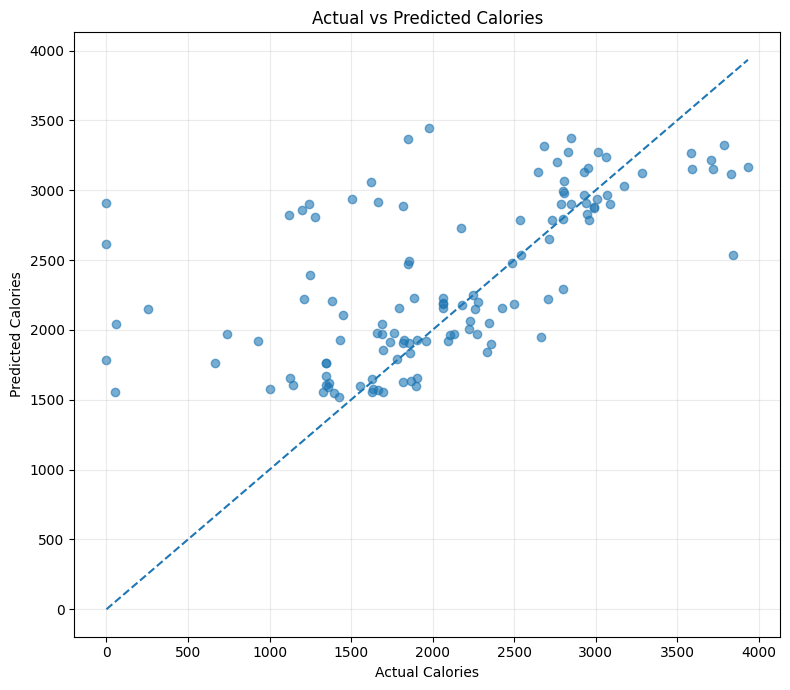

In [14]:
# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

print("=" * 70)
print("ACTUAL VS PREDICTED")
print("=" * 70)

plt.figure(figsize=(8, 7))

plt.scatter(
    predictions_df["ActualCalories"],
    predictions_df["PredictedCalories"],
    alpha=0.6
)

# Perfect prediction line
min_value = min(
    predictions_df["ActualCalories"].min(),
    predictions_df["PredictedCalories"].min()
)

max_value = max(
    predictions_df["ActualCalories"].max(),
    predictions_df["PredictedCalories"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted Calories")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

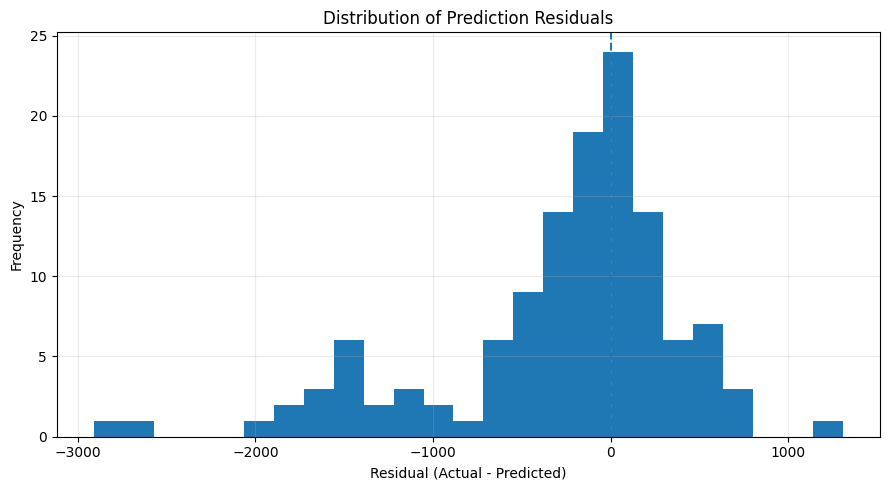

In [15]:
# ============================================================
# RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    predictions_df["Residual"],
    bins=25
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Residuals")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

ERROR VS ACTUAL


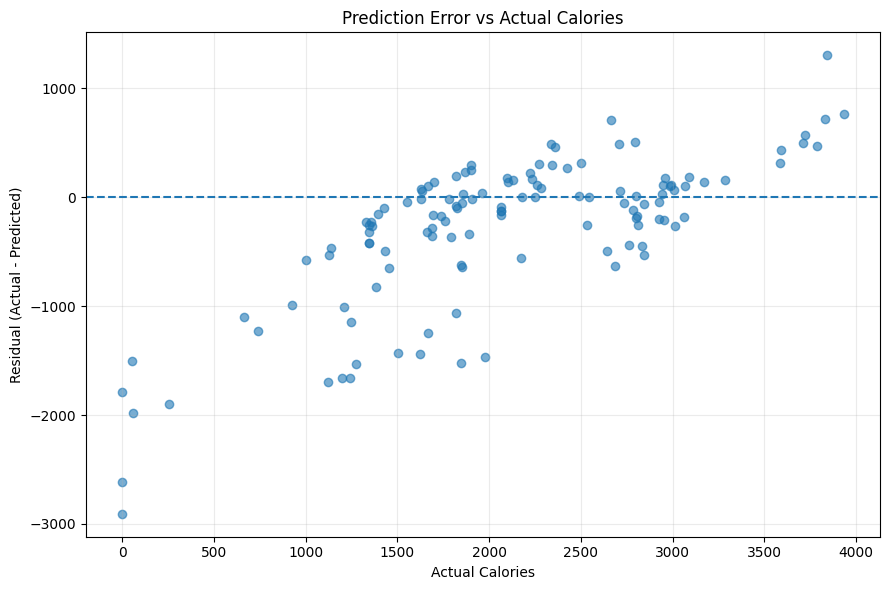

In [16]:
# ============================================================
# ERROR VS ACTUAL
# ============================================================

print("=" * 70)
print("ERROR VS ACTUAL")
print("=" * 70)

plt.figure(figsize=(9, 6))

plt.scatter(
    predictions_df["ActualCalories"],
    predictions_df["Residual"],
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Actual Calories")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Prediction Error vs Actual Calories")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# ZERO-TARGET ERROR INSPECTION
# ============================================================

zero_target = predictions_df[
    predictions_df["ActualCalories"] == 0
].copy()

print("=" * 70)
print("ZERO-TARGET PREDICTIONS")
print("=" * 70)

print(f"Zero-target observations: {len(zero_target)}")

display(
    zero_target[
        [
            "Id",
            "ActivityDate",
            "ActualCalories",
            "PredictedCalories",
            "Residual",
            "AbsoluteError"
        ]
    ].round(2)
)

ZERO-TARGET PREDICTIONS
Zero-target observations: 3


,Id,ActivityDate,ActualCalories,PredictedCalories,Residual,AbsoluteError
22,1503960366,2016-05-11,0.0,1787.24,-1787.24,1787.24
473,6290855005,2016-05-09,0.0,2613.70,-2613.70,2613.70
635,8583815059,2016-05-11,0.0,2907.00,-2907.00,2907.00


In [18]:
# ============================================================
# ERROR BY TARGET TYPE
# ============================================================

zero_mae = (
    zero_target["AbsoluteError"].mean()
    if len(zero_target) > 0
    else np.nan
)

nonzero_mae = (
    predictions_df.loc[
        predictions_df["ActualCalories"] != 0,
        "AbsoluteError"
    ].mean()
)

error_groups = pd.DataFrame({
    "group": [
        "Zero target",
        "Non-zero target"
    ],
    "MAE": [
        zero_mae,
        nonzero_mae
    ],
    "observations": [
        len(zero_target),
        (predictions_df["ActualCalories"] != 0).sum()
    ]
})

display(error_groups.round(2))

,group,MAE,observations
0,Zero target,2435.98,3
1,Non-zero target,439.26,122


модель демонструє суттєво вищу похибку для трьох спостережень із нульовим цільовим значенням; ці спостереження були збережені у тестовій вибірці, оскільки їх автоматичне видалення могло б штучно покращити оцінку моделі.

In [19]:
# ============================================================
# USER-LEVEL ERROR ANALYSIS
# ============================================================

print("=" * 70)
print("USER-LEVEL ERROR ANALYSIS")
print("=" * 70)

user_errors = (
    predictions_df
    .groupby("Id")
    .agg(
        observations=("AbsoluteError", "count"),
        MAE=("AbsoluteError", "mean"),
        RMSE=("Residual", lambda x: np.sqrt(np.mean(x ** 2))),
        MeanResidual=("Residual", "mean")
    )
    .sort_values("MAE", ascending=False)
)

display(
    user_errors.round(2)
)

USER-LEVEL ERROR ANALYSIS


,observations,MAE,RMSE,MeanResidual
Id,,,,
6290855005,3,1075.97,1543.17,-1037.29
5577150313,4,906.96,1048.46,-250.38
8792009665,3,875.44,1175.79,-875.44
8877689391,5,741.32,842.22,-255.59
8378563200,5,691.17,799.51,-149.11
8583815059,5,656.61,1303.67,-598.45
6117666160,2,572.38,809.27,-572.10
4388161847,5,569.74,747.24,-262.70
4319703577,5,567.70,878.33,-337.68


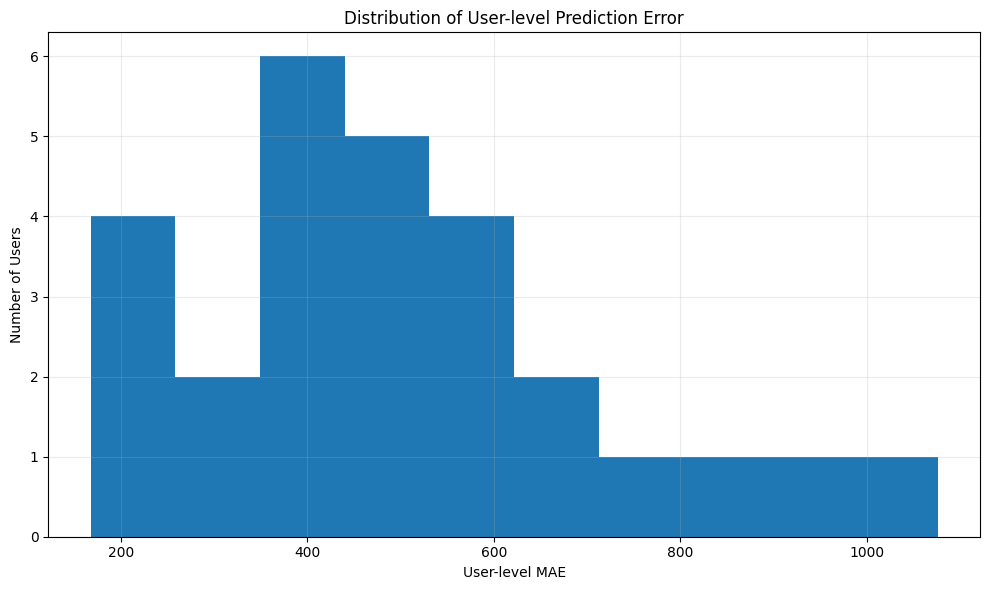

In [20]:
plt.figure(figsize=(10, 6))

plt.hist(
    user_errors["MAE"],
    bins=10
)

plt.xlabel("User-level MAE")
plt.ylabel("Number of Users")
plt.title("Distribution of User-level Prediction Error")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# USER-LEVEL BIAS
# ============================================================

print("=" * 70)
print("USER-LEVEL PREDICTION BIAS")
print("=" * 70)

user_bias = (
    predictions_df
    .groupby("Id")
    .agg(
        observations=("Residual", "count"),
        MeanResidual=("Residual", "mean"),
        MedianResidual=("Residual", "median")
    )
    .sort_values("MeanResidual")
)

display(
    user_bias.round(2)
)

USER-LEVEL PREDICTION BIAS


,observations,MeanResidual,MedianResidual
Id,,,
6290855005,3,-1037.29,-556.18
8792009665,3,-875.44,-355.46
8583815059,5,-598.45,-57.52
6117666160,2,-572.10,-572.10
1844505072,5,-500.99,-416.38
4020332650,5,-431.63,-117.21
1503960366,5,-406.50,-84.40
1644430081,4,-387.60,-62.25
8053475328,5,-379.64,-258.57


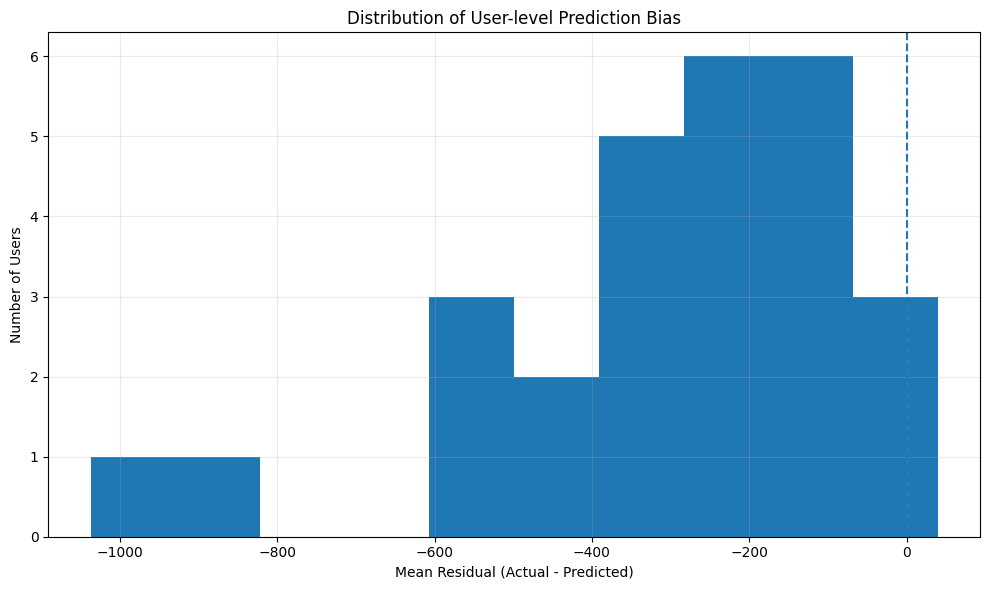

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    user_bias["MeanResidual"],
    bins=10
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Mean Residual (Actual - Predicted)")
plt.ylabel("Number of Users")
plt.title("Distribution of User-level Prediction Bias")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# SHAP INTERPRETABILITY
# ============================================================

print("=" * 70)
print("SHAP INTERPRETABILITY")
print("=" * 70)

try:
    import shap
    print(f"SHAP version: {shap.__version__}")
except ImportError:
    !pip install shap -q
    import shap
    print(f"SHAP version: {shap.__version__}")

print("\nCreating TreeExplainer...")

explainer = shap.TreeExplainer(rf_model)

print("TreeExplainer created.")

SHAP INTERPRETABILITY
SHAP version: 0.52.0

Creating TreeExplainer...
TreeExplainer created.


In [23]:
# ============================================================
# SHAP VALUES
# ============================================================

print("=" * 70)
print("CALCULATING SHAP VALUES")
print("=" * 70)

shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Test data shape:   {X_test.shape}")

CALCULATING SHAP VALUES
SHAP values shape: (125, 65)
Test data shape:   (125, 65)


In [24]:
# ============================================================
# SHAP GLOBAL FEATURE IMPORTANCE
# ============================================================

shap_importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("=" * 70)
print("SHAP GLOBAL FEATURE IMPORTANCE")
print("=" * 70)

display(
    shap_importance.head(20).round(6)
)

SHAP GLOBAL FEATURE IMPORTANCE


,feature,mean_abs_shap
0,Calories_rolling_mean_7,358.609356
1,Calories,105.385067
2,Calories_rolling_mean_3,46.237828
3,Calories_lag_2,26.436414
4,Calories_lag_1,25.470597
5,LightlyActiveMinutes_lag_1,14.691966
6,Calories_lag_7,7.183419
7,LightlyActiveMinutes_rolling_mean_7,6.416230
8,SedentaryMinutes,6.162882
9,SedentaryMinutes_rolling_std_7,5.744198


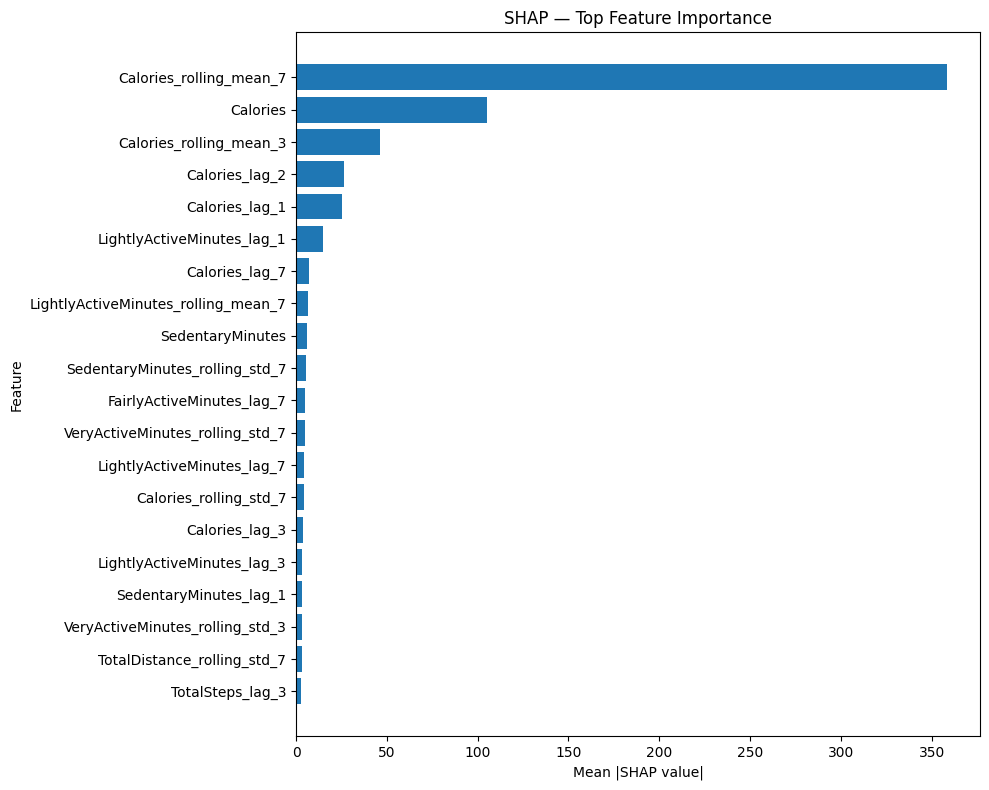

In [25]:
# ============================================================
# SHAP FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(10, 8))

top_shap = shap_importance.head(20).sort_values(
    "mean_abs_shap",
    ascending=True
)

plt.barh(
    top_shap["feature"],
    top_shap["mean_abs_shap"]
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title("SHAP — Top Feature Importance")

plt.tight_layout()
plt.show()

SHAP SUMMARY — FEATURE IMPACT


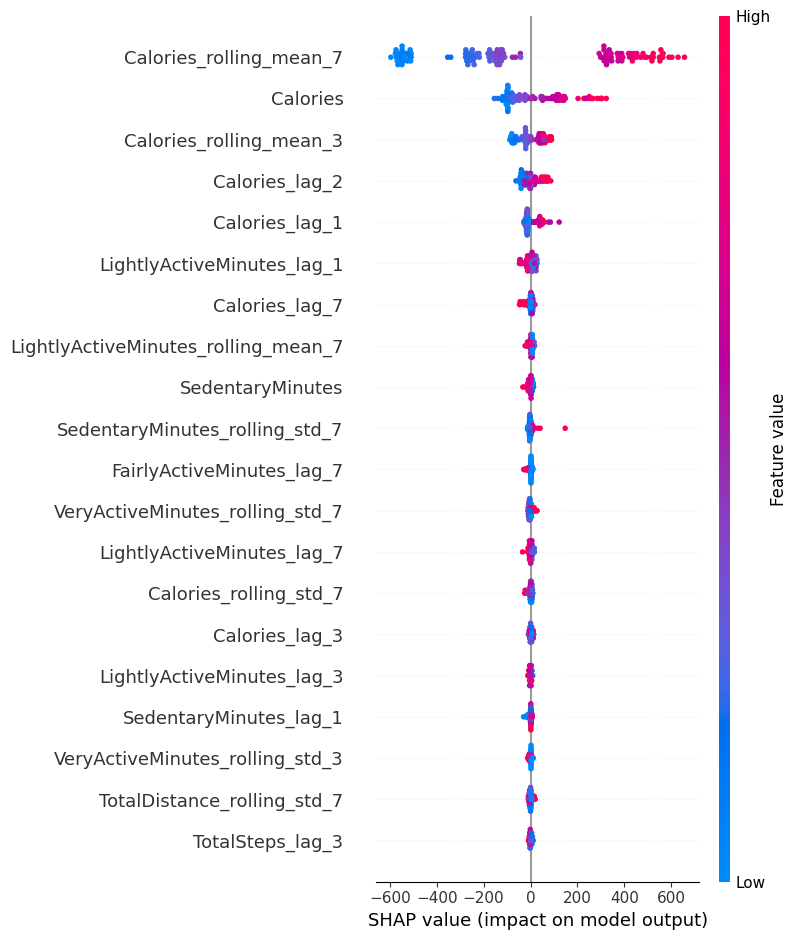

In [26]:
# ============================================================
# SHAP SUMMARY / BEESWARM
# ============================================================

print("=" * 70)
print("SHAP SUMMARY — FEATURE IMPACT")
print("=" * 70)

shap.summary_plot(
    shap_values,
    X_test,
    max_display=20,
    show=True
)

SHAP DEPENDENCE — Calories_rolling_mean_7


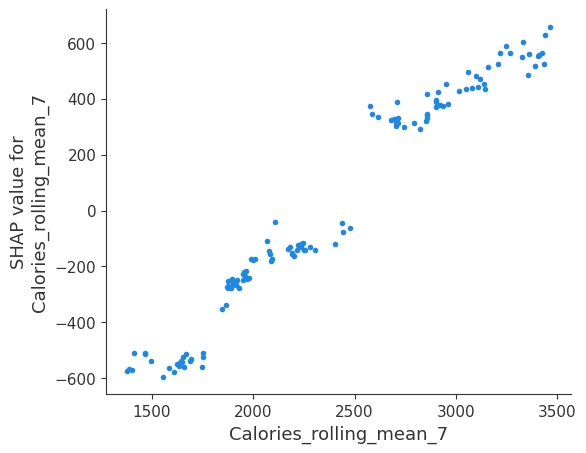

In [27]:
# ============================================================
# SHAP DEPENDENCE — DOMINANT FEATURE
# ============================================================

print("=" * 70)
print("SHAP DEPENDENCE — Calories_rolling_mean_7")
print("=" * 70)

shap.dependence_plot(
    "Calories_rolling_mean_7",
    shap_values,
    X_test,
    interaction_index=None,
    show=True
)

SHAP LOCAL EXPLANATIONS

----------------------------------------------------------------------
Test row: 159
Actual:    1364.00
Predicted: 1623.20
Residual:  -259.20


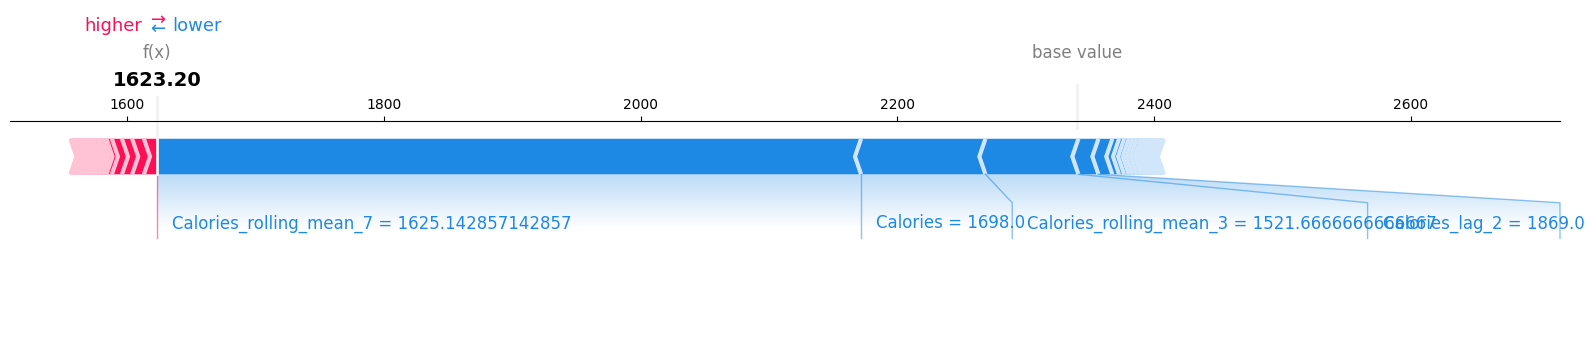


----------------------------------------------------------------------
Test row: 635
Actual:    0.00
Predicted: 2907.00
Residual:  -2907.00


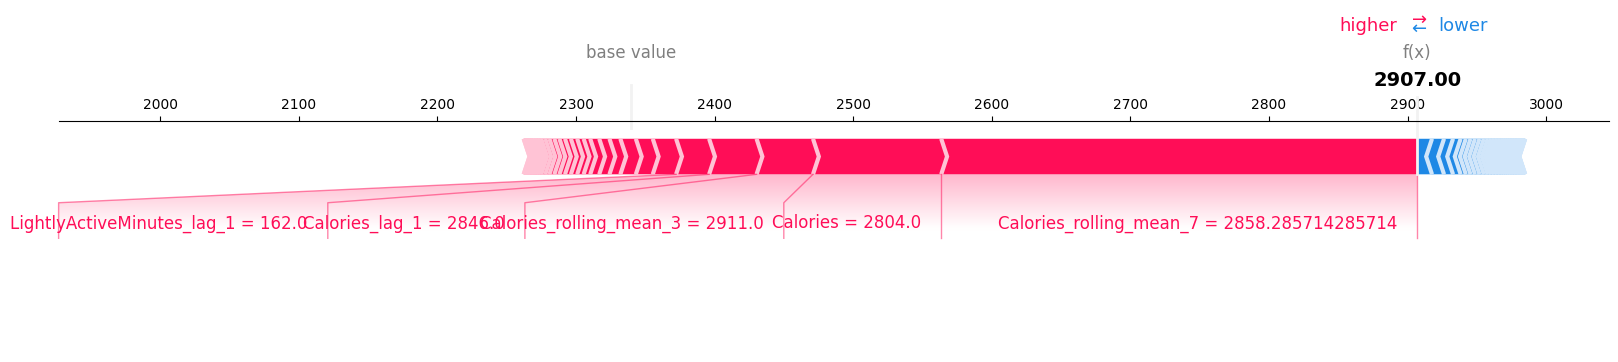


----------------------------------------------------------------------
Test row: 431
Actual:    3841.00
Predicted: 2536.46
Residual:  1304.54


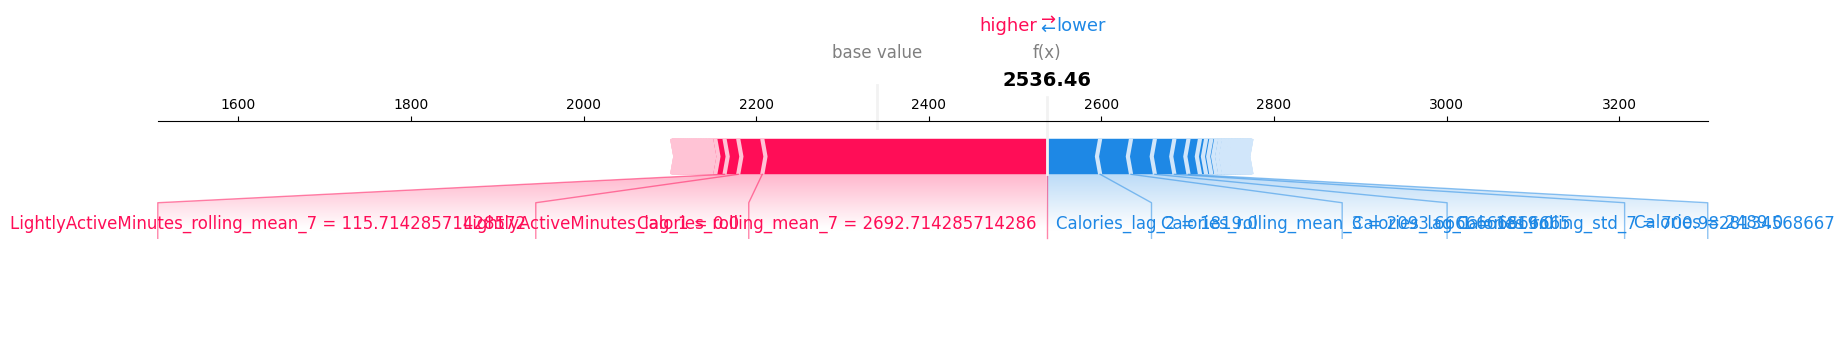

In [29]:
print("=" * 70)
print("SHAP LOCAL EXPLANATIONS")
print("=" * 70)

# Find representative cases
worst_over = predictions_df["Residual"].idxmin()
worst_under = predictions_df["Residual"].idxmax()

absolute_error = predictions_df["AbsoluteError"]
typical_idx = (
    absolute_error
    - absolute_error.median()
).abs().idxmin()

selected_indices = [
    typical_idx,
    worst_over,
    worst_under
]

for idx in selected_indices:
    test_position = X_test.index.get_loc(idx)

    actual = predictions_df.loc[idx, "ActualCalories"]
    predicted = predictions_df.loc[idx, "PredictedCalories"]
    residual = predictions_df.loc[idx, "Residual"]

    print("\n" + "-" * 70)
    print(f"Test row: {idx}")
    print(f"Actual:    {actual:.2f}")
    print(f"Predicted: {predicted:.2f}")
    print(f"Residual:  {residual:.2f}")

    shap.force_plot(
        explainer.expected_value,
        shap_values[test_position],
        X_test.loc[idx],
        matplotlib=True,
        show=True
    )

print("=" * 70)

In [30]:
# ============================================================
# 008 — CLEAN FINAL EXPORT
# ============================================================

from pathlib import Path
import json
import joblib

OUTPUT_DIR = (
    Path(config.PROJECT_DIR)
    / "results"
    / "008_interpretability"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("008 — FINAL EXPORT")
print("=" * 70)

required_objects = [
    "rf_model",
    "X_test",
    "predictions_df",
    "user_errors",
    "user_bias",
    "shap_values",
    "shap_importance",
]

missing = [name for name in required_objects if name not in globals()]
if missing:
    raise RuntimeError(
        "008 analysis is incomplete. Missing: " + ", ".join(missing)
    )

# Tables
predictions_df.to_csv(OUTPUT_DIR / "prediction_results.csv", index=False)
user_errors.to_csv(OUTPUT_DIR / "user_level_errors.csv")
user_bias.to_csv(OUTPUT_DIR / "user_level_bias.csv")
shap_importance.to_csv(
    OUTPUT_DIR / "shap_global_importance.csv",
    index=False
)

shap_values_df = pd.DataFrame(
    shap_values,
    columns=X_test.columns,
    index=X_test.index
)
shap_values_df.to_csv(
    OUTPUT_DIR / "shap_values_test.csv",
    index=True
)

# Model
joblib.dump(
    rf_model,
    OUTPUT_DIR / "random_forest_reference.pkl"
)

# Metadata
metadata = {
    "model": "Random Forest — All Features",
    "target": target_column,
    "split_date": split_date.strftime("%Y-%m-%d"),
    "train_rows": int(len(train)),
    "test_rows": int(len(test)),
    "feature_count": int(X_test.shape[1]),
    "users_train": int(train["Id"].nunique()),
    "users_test": int(test["Id"].nunique()),
    "MAE": float(mae),
    "RMSE": float(rmse),
    "R2": float(r2),
    "n_estimators": int(rf_model.n_estimators),
    "max_depth": int(rf_model.max_depth),
    "min_samples_leaf": int(rf_model.min_samples_leaf),
    "random_state": int(rf_model.random_state),
    "zero_target_observations": int(len(zero_target)),
    "dominant_SHAP_feature": str(
        shap_importance.iloc[0]["feature"]
    ),
}

with open(
    OUTPUT_DIR / "model_metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

# Export the three local cases as a compact table.
local_rows = []
for label, idx in [
    ("typical", typical_idx),
    ("largest_overprediction", worst_over),
    ("largest_underprediction", worst_under),
]:
    local_rows.append({
        "case": label,
        "row_index": int(idx),
        "Id": predictions_df.loc[idx, "Id"],
        "ActivityDate": str(
            predictions_df.loc[idx, "ActivityDate"]
        ),
        "ActualCalories": float(
            predictions_df.loc[idx, "ActualCalories"]
        ),
        "PredictedCalories": float(
            predictions_df.loc[idx, "PredictedCalories"]
        ),
        "Residual": float(
            predictions_df.loc[idx, "Residual"]
        ),
        "AbsoluteError": float(
            predictions_df.loc[idx, "AbsoluteError"]
        ),
    })

pd.DataFrame(local_rows).to_csv(
    OUTPUT_DIR / "shap_local_cases.csv",
    index=False
)

print("\n✓ 008 export complete")
for path in sorted(OUTPUT_DIR.iterdir()):
    if path.is_file():
        print(f"  ✓ {path.name}")


008 — FINAL EXPORT

✓ 008 export complete
  ✓ model_metadata.json
  ✓ prediction_results.csv
  ✓ random_forest_reference.pkl
  ✓ shap_global_importance.csv
  ✓ shap_local_cases.csv
  ✓ shap_values_test.csv
  ✓ user_level_bias.csv
  ✓ user_level_errors.csv
